Cell 1  → imports (pandas, matplotlib, seaborn)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Cell 2  → BigQuery connection + load data (the query we just fixed)

In [3]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="sctp-team2-project2-elt")

query = """
SELECT
    f.id                                AS order_id,
    f.customer_id,
    f.order_status,
    f.order_purchase_timestamp,
    f.order_delivered_customer_date,
    f.order_estimated_delivery_date,
    r.review_score,
    c.customer_unique_id,

    DATE_DIFF(
        DATE(f.order_delivered_customer_date),
        DATE(f.order_estimated_delivery_date),
        DAY
    ) AS delivery_delay_days

FROM `sctp-team2-project2-elt.olist_gold_mart_prod.fact_orders` f
LEFT JOIN `sctp-team2-project2-elt.olist_bronze_prod.olist_order_reviews_raw` r
    ON f.id = r.order_id
LEFT JOIN `sctp-team2-project2-elt.olist_bronze_prod.olist_customers_raw` c
    ON f.customer_id = c.customer_id

WHERE f.order_status = 'delivered'
  AND f.order_delivered_customer_date IS NOT NULL
  AND f.order_estimated_delivery_date IS NOT NULL
  AND f.has_invalid_delivery_date = FALSE
  AND f.has_missing_delivery_date = FALSE
"""

df = client.query(query).to_dataframe()
print(f"Rows loaded: {len(df)}")
df.head()

/opt/anaconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Rows loaded: 110832


,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,review_score,customer_unique_id,delivery_delay_days
0,0b7cb1c7ea62d95ba39702f4ae850108,2d618e470c95c9b425cbb0cbc42683dd,delivered,2018-04-10 18:21:13+00:00,2018-06-21 23:06:47+00:00,2018-05-21 00:00:00+00:00,1,f7d7fc0a59ef4363fdce6e3aa069d498,31
1,c3ad507aba1f6b47354085e7e6bed0cf,5156283c24fef4abea13a6a6f4469a98,delivered,2017-01-21 19:46:23+00:00,2017-02-09 15:44:10+00:00,2017-03-15 00:00:00+00:00,2,28989ef45087c96e5a4346e88216c2ba,-34
2,c3ad507aba1f6b47354085e7e6bed0cf,5156283c24fef4abea13a6a6f4469a98,delivered,2017-01-21 19:46:23+00:00,2017-02-09 15:44:10+00:00,2017-03-15 00:00:00+00:00,2,28989ef45087c96e5a4346e88216c2ba,-34
3,c3ad507aba1f6b47354085e7e6bed0cf,5156283c24fef4abea13a6a6f4469a98,delivered,2017-01-21 19:46:23+00:00,2017-02-09 15:44:10+00:00,2017-03-15 00:00:00+00:00,2,28989ef45087c96e5a4346e88216c2ba,-34
4,aaf067f5adccd2b8fdf1a9f651a9148a,62aaae3eaf6f655d97919594b388feaa,delivered,2018-06-16 15:30:56+00:00,2018-06-29 21:07:08+00:00,2018-08-02 00:00:00+00:00,4,057e56752630652c673205286270e5a3,-34


Cell 2 Dedup → there are duplicate rows (rows 1, 2, 3 are the same order_id). This is because the reviews table has multiple reviews per order. Let's deduplicate before charting by adding a dedup step.

In [4]:
# Deduplicate - keep one review per order (highest score if multiple)
df = df.sort_values('review_score', ascending=False)
df = df.drop_duplicates(subset='order_id', keep='first')

print(f"Rows after dedup: {len(df)}")
print(f"Delivery delay range: {df['delivery_delay_days'].min()} to {df['delivery_delay_days'].max()} days")
print(f"Avg review score: {df['review_score'].mean():.2f}")
df.head()

Rows after dedup: 96470
Delivery delay range: -147 to 188 days
Avg review score: 4.16


,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,review_score,customer_unique_id,delivery_delay_days
55451,c6d5501e88e1bdffbc13792a7f4dadda,0581c965ce68e0b4be312e116c15a31a,delivered,2018-05-10 15:47:59+00:00,2018-05-15 18:24:54+00:00,2018-05-28 00:00:00+00:00,5,91a116717ec31215ffc38c8cab031a6e,-13
94735,1e183518cf69a3f47a8f2de2105a1c16,2472db5dcd1737948d7c75037c8d9ebb,delivered,2017-11-22 20:58:02+00:00,2017-11-28 19:39:58+00:00,2017-12-04 00:00:00+00:00,5,99eb34555f2b022b5c8cf242b9802e78,-6
53760,92841cc24435590294fb25f6938e295e,326d2b73d71fadf278bb58a956acaeae,delivered,2018-05-16 21:36:57+00:00,2018-05-22 16:07:47+00:00,2018-06-04 00:00:00+00:00,5,49343026d5db179532d1881e55e9127e,-13
53759,e2c5cdd2687cb2f0efe991ed155c8653,b686164fb97b8faf0c6acb1556838ed1,delivered,2018-05-07 18:23:49+00:00,2018-05-16 14:13:06+00:00,2018-05-29 00:00:00+00:00,5,5874919973f2990196b3a832ac6e4274,-13
53758,7a4380b2d852be9f98a57d31d6a9c51b,837343b368cfbcf883cb6968069b5b2b,delivered,2017-06-29 11:52:18+00:00,2017-07-12 17:32:36+00:00,2017-07-25 00:00:00+00:00,5,eb3450b02bf04cc3a099f24b7719da84,-13


Cell 3  → Chart 1: Delivery Delay Distribution

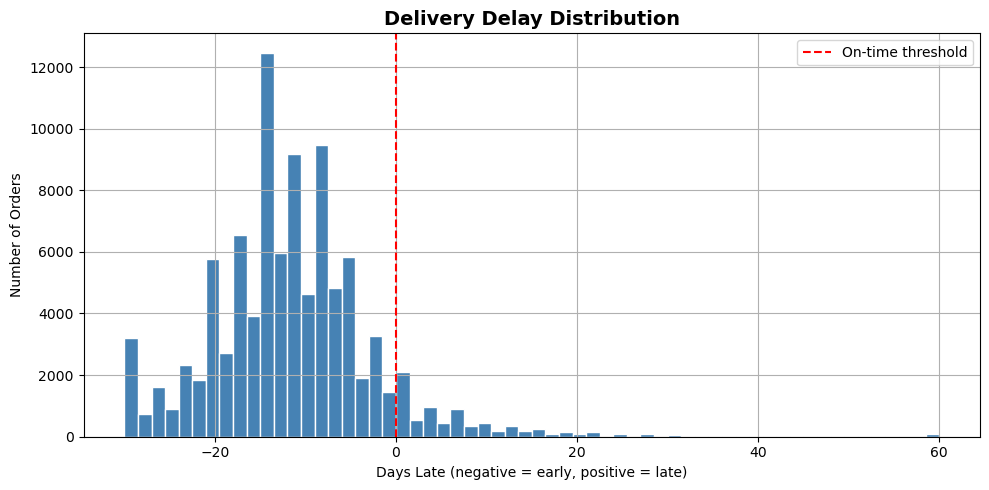

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

df['delivery_delay_days'].clip(-30, 60).hist(
    bins=60, color='steelblue', edgecolor='white', ax=ax
)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='On-time threshold')
ax.set_title('Delivery Delay Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Days Late (negative = early, positive = late)')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.savefig('chart1_delivery_delay.png', dpi=150)
plt.show()

Cell 4  → Chart 2: Avg Review Score by Delay Bucket

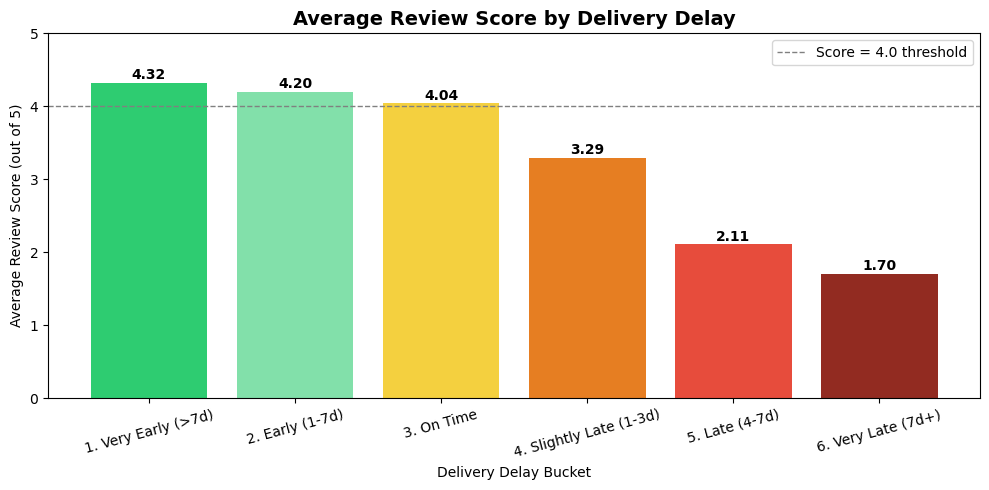

In [6]:
def delay_bucket(days):
    if days < -7:
        return '1. Very Early (>7d)'
    elif days < 0:
        return '2. Early (1-7d)'
    elif days == 0:
        return '3. On Time'
    elif days <= 3:
        return '4. Slightly Late (1-3d)'
    elif days <= 7:
        return '5. Late (4-7d)'
    else:
        return '6. Very Late (7d+)'

df['delay_bucket'] = df['delivery_delay_days'].apply(delay_bucket)

bucket_scores = df.groupby('delay_bucket')['review_score'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71', '#82e0aa', '#f4d03f', '#e67e22', '#e74c3c', '#922b21']
bars = ax.bar(bucket_scores['delay_bucket'], bucket_scores['review_score'], color=colors)
ax.set_ylim(0, 5)
ax.axhline(4.0, color='gray', linestyle='--', linewidth=1, label='Score = 4.0 threshold')

# Add value labels on top of each bar
for bar, val in zip(bars, bucket_scores['review_score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Average Review Score by Delivery Delay', fontsize=14, fontweight='bold')
ax.set_xlabel('Delivery Delay Bucket')
ax.set_ylabel('Average Review Score (out of 5)')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart2_score_by_delay.png', dpi=150)
plt.show()

Cell 5  → Chart 3: Repeat Purchase Rate by Review Score

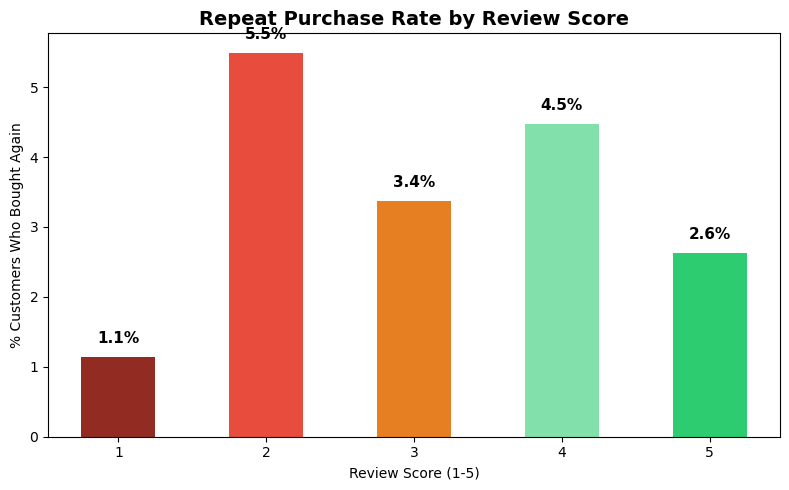

In [7]:
# Count orders and avg review per unique customer
repeat = df.groupby('customer_unique_id').agg(
    total_orders=('order_id', 'nunique'),
    avg_review=('review_score', 'mean')
).reset_index()

repeat['is_repeat'] = repeat['total_orders'] > 1

# Repeat rate by review score (rounded to nearest whole number)
repeat_rate = repeat.groupby(
    repeat['avg_review'].round()
)['is_repeat'].mean().reset_index()

repeat_rate.columns = ['review_score', 'repeat_rate']
repeat_rate['repeat_rate_pct'] = repeat_rate['repeat_rate'] * 100

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#922b21', '#e74c3c', '#e67e22', '#82e0aa', '#2ecc71']
bars = ax.bar(repeat_rate['review_score'].astype(int), 
              repeat_rate['repeat_rate_pct'], 
              color=colors, width=0.5)

# Add value labels
for bar, val in zip(bars, repeat_rate['repeat_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Repeat Purchase Rate by Review Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Review Score (1-5)')
ax.set_ylabel('% Customers Who Bought Again')
ax.set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.savefig('chart3_repeat_by_score.png', dpi=150)
plt.show()

Check quantity of customers in each bucket

In [8]:
# Check how many customers are in each bucket
repeat_count = repeat.groupby(
    repeat['avg_review'].round()
).agg(
    total_customers=('customer_unique_id', 'count'),
    repeat_customers=('is_repeat', 'sum'),
    repeat_rate_pct=('is_repeat', lambda x: x.mean() * 100)
).reset_index()

repeat_count.columns = ['review_score', 'total_customers', 'repeat_customers', 'repeat_rate_pct']
print(repeat_count)

   review_score  total_customers  repeat_customers  repeat_rate_pct
0           1.0             8914               102         1.144267
1           2.0             2912               160         5.494505
2           3.0             7701               260         3.376185
3           4.0            18695               837         4.477133
4           5.0            54525              1433         2.628152


Cell 5 Option B — Volume of Low Reviews Caused by Late Delivery
This reframes the story as: "How many 1-star reviews are we generating, and how many of them are directly caused by late delivery?"

             label  total_orders  low_score_orders  low_score_pct
0  On-Time / Early         89443              8248       9.221515
1    Late Delivery          6381              3976      62.309983


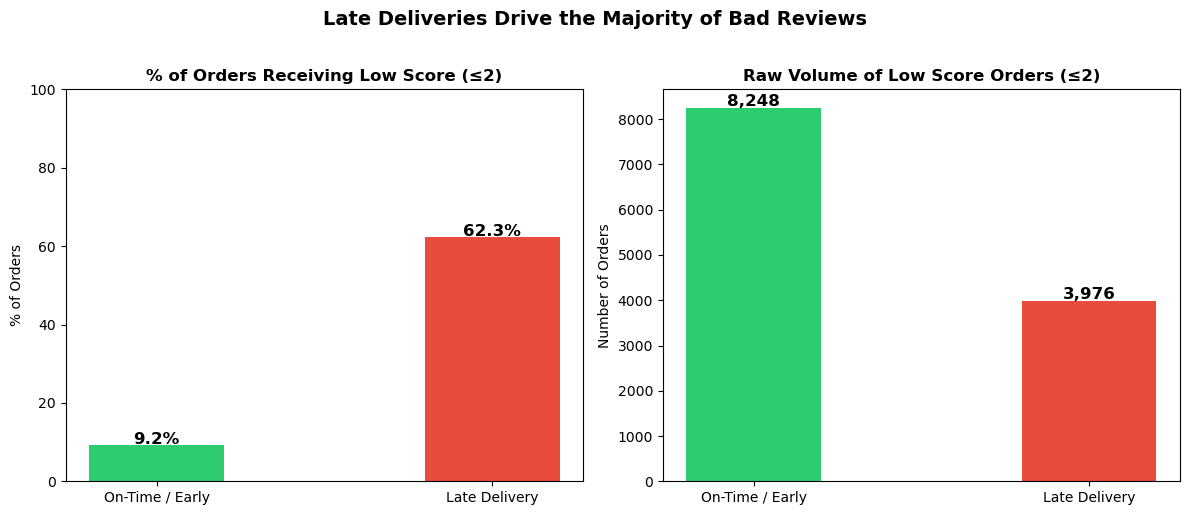

In [9]:
# Categorise orders into late vs on-time
df['is_late'] = df['delivery_delay_days'] > 0
df['is_low_score'] = df['review_score'] <= 2

# Count low scores by late vs on-time
low_score_summary = df.groupby('is_late')['is_low_score'].agg(
    total_orders='count',
    low_score_orders='sum'
).reset_index()

low_score_summary['low_score_pct'] = (
    low_score_summary['low_score_orders'] / low_score_summary['total_orders'] * 100
)
low_score_summary['label'] = low_score_summary['is_late'].map({
    False: 'On-Time / Early',
    True: 'Late Delivery'
})

print(low_score_summary[['label', 'total_orders', 'low_score_orders', 'low_score_pct']])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left chart: % of low scores
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(
    low_score_summary['label'],
    low_score_summary['low_score_pct'],
    color=colors, width=0.4
)
for bar, val in zip(bars, low_score_summary['low_score_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

axes[0].set_title('% of Orders Receiving Low Score (≤2)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% of Orders')
axes[0].set_ylim(0, 100)

# --- Right chart: raw volume of low scores
bars2 = axes[1].bar(
    low_score_summary['label'],
    low_score_summary['low_score_orders'],
    color=colors, width=0.4
)
for bar, val in zip(bars2, low_score_summary['low_score_orders']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{int(val):,}', ha='center', fontsize=12, fontweight='bold')

axes[1].set_title('Raw Volume of Low Score Orders (≤2)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Orders')

plt.suptitle('Late Deliveries Drive the Majority of Bad Reviews',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart3_late_low_scores.png', dpi=150)
plt.show()

Geographical Map

In [10]:
# Option A - Query: avg review score + delivery delay by state
query_geo = """
SELECT
    c.customer_state,
    AVG(r.review_score)                         AS avg_review_score,
    AVG(DATE_DIFF(
        DATE(f.order_delivered_customer_date),
        DATE(f.order_estimated_delivery_date),
        DAY
    ))                                           AS avg_delay_days,
    COUNT(f.id)                                  AS total_orders

FROM `sctp-team2-project2-elt.olist_gold_mart_prod.fact_orders` f
LEFT JOIN `sctp-team2-project2-elt.olist_bronze_prod.olist_order_reviews_raw` r
    ON f.id = r.order_id
LEFT JOIN `sctp-team2-project2-elt.olist_bronze_prod.olist_customers_raw` c
    ON f.customer_id = c.customer_id

WHERE f.order_status = 'delivered'
  AND f.order_delivered_customer_date IS NOT NULL
  AND f.order_estimated_delivery_date IS NOT NULL
  AND f.has_invalid_delivery_date = FALSE
  AND f.has_missing_delivery_date = FALSE
  AND c.customer_state IS NOT NULL

GROUP BY c.customer_state
ORDER BY avg_review_score ASC
"""

df_geo = client.query(query_geo).to_dataframe()
print(f"States loaded: {len(df_geo)}")
print(df_geo)

/opt/anaconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


States loaded: 28
   customer_state  avg_review_score  avg_delay_days  total_orders
0              MA          3.765957       -9.996273           805
1              AL          3.815421       -8.740139           431
2              PA          3.842459      -14.228087          1061
3              BA          3.860725      -10.978666          3703
4              CE          3.867275      -11.138365          1431
5              RJ          3.871611      -11.998242         14224
6              RR          3.891304      -18.326087            46
7              SE          3.898123      -10.002667           375
8              PI          3.961464      -11.519084           524
9              MT          4.008746      -14.599038          1040
10             ES          4.017234      -10.658318          2236
11             PE          4.022989      -13.504551          1758
12             GO          4.038462      -12.317806          2297
13             PB          4.039587      -13.051107       

In [12]:
print(brazil.columns.tolist())
print(brazil.head(3))

['id', 'FID_Export', 'SIGLA', 'Total', 'Homens', 'Mulheres', 'Urbana', 'Rural', 'TX_Alfab', 'FID_estado', 'Estado', 'FK_macro', 'PK_sigla', 'geometry']
   id  FID_Export SIGLA    Total   Homens  Mulheres   Urbana   Rural  \
0  AC           0    AC   557526   280983    276543   370267  187259   
1  AL           1    AL  2822621  1378942   1443679  1919739  902882   
2  AM           2    AM  2812557  1414367   1398190  2107222  705335   

    TX_Alfab  FID_estado    Estado FK_macro PK_sigla  \
0  65.154545          -1      Acre        N       AC   
1  59.364356          -1   Alagoas       NE       AL   
2  72.250000          -1  Amazonas        N       AM   

                                            geometry  
0  MULTIPOLYGON (((-66.80619 -9.81446, -66.64485 ...  
1  MULTIPOLYGON (((-35.15263 -8.91373, -35.15628 ...  
2  MULTIPOLYGON (((-67.3259 2.02976, -67.30001 1....  


Map Cell

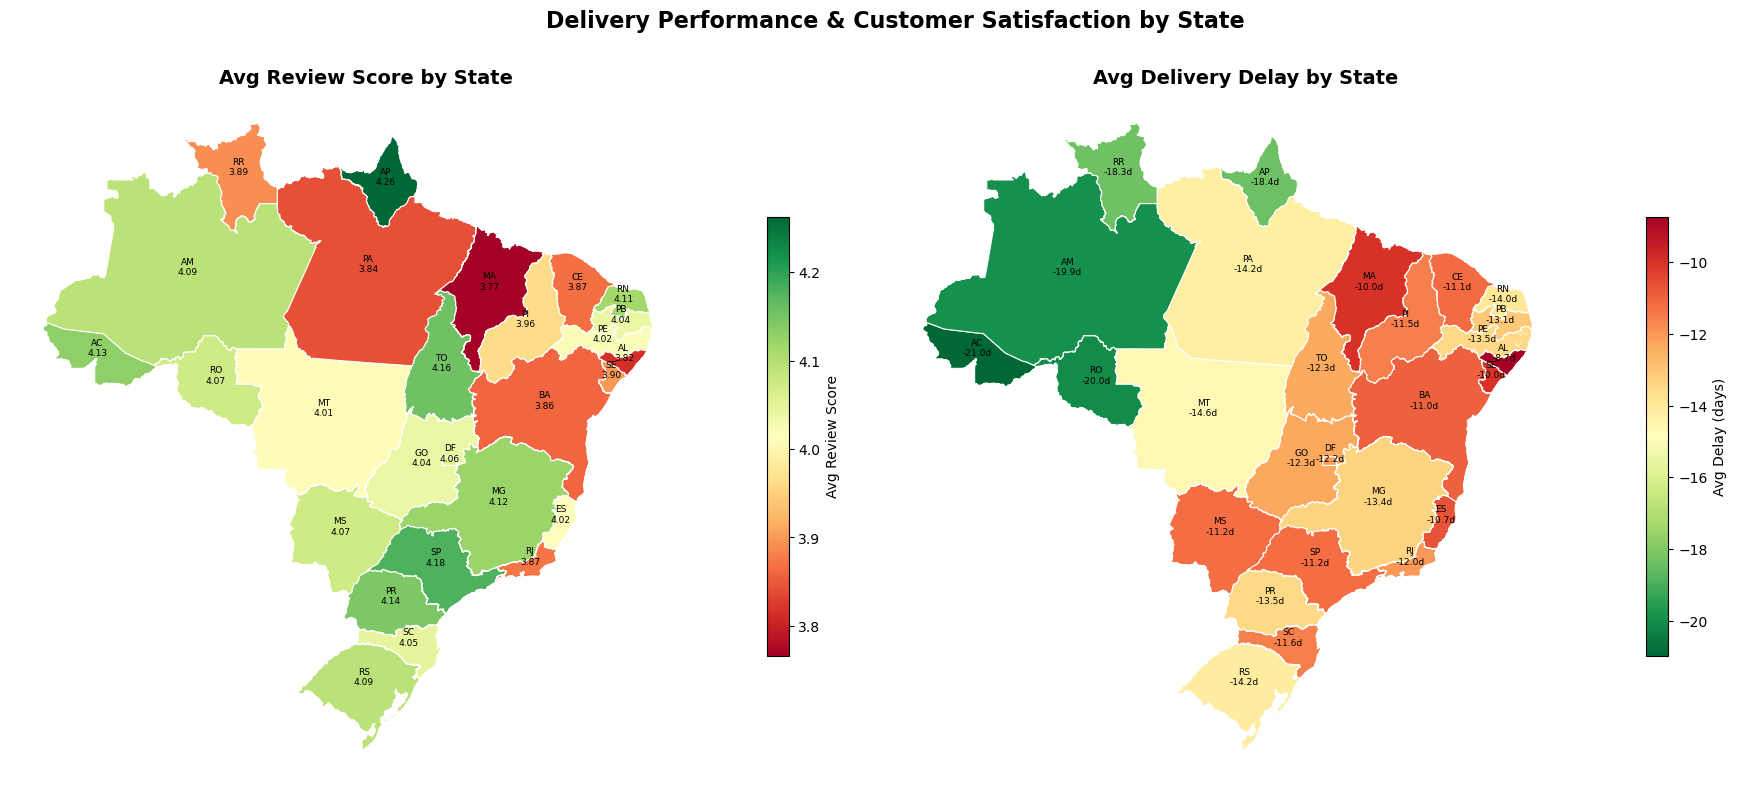

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Merge directly on SIGLA since it already matches customer_state (e.g. 'SP', 'RJ')
brazil_merged = brazil.merge(df_geo, left_on='SIGLA', right_on='customer_state', how='left')

# --- Plot side by side: review score + avg delay
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Map 1 — Avg Review Score by State
brazil_merged.plot(
    column='avg_review_score',
    cmap='RdYlGn',
    linewidth=0.8,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Avg Review Score', 'shrink': 0.6},
    ax=axes[0],
    missing_kwds={'color': 'lightgrey'}
)
axes[0].set_title('Avg Review Score by State', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Add state labels
for _, row in brazil_merged.iterrows():
    if row['SIGLA'] and row['avg_review_score']:
        centroid = row['geometry'].centroid
        axes[0].annotate(
            f"{row['SIGLA']}\n{row['avg_review_score']:.2f}",
            xy=(centroid.x, centroid.y),
            ha='center', fontsize=6.5, color='black'
        )

# Map 2 — Avg Delivery Delay by State
brazil_merged.plot(
    column='avg_delay_days',
    cmap='RdYlGn_r',
    linewidth=0.8,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Avg Delay (days)', 'shrink': 0.6},
    ax=axes[1],
    missing_kwds={'color': 'lightgrey'}
)
axes[1].set_title('Avg Delivery Delay by State', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Add state labels
for _, row in brazil_merged.iterrows():
    if row['SIGLA'] and row['avg_delay_days']:
        centroid = row['geometry'].centroid
        axes[1].annotate(
            f"{row['SIGLA']}\n{row['avg_delay_days']:.1f}d",
            xy=(centroid.x, centroid.y),
            ha='center', fontsize=6.5, color='black'
        )

plt.suptitle('Delivery Performance & Customer Satisfaction by State',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart_geo_map.png', dpi=150, bbox_inches='tight')
plt.show()